# 03 — Model Training

**Goal:** Train and evaluate two classifiers, compare them honestly.

Checkpoints covered:
- **3.1** — TF-IDF vectorizer built
- **3.2** — Layer 1: Logistic Regression baseline trained and saved
- **3.3** — Layer 1 evaluated (confusion matrix, F1, top predictive words)
- **4.1** — Sentence embeddings built
- **4.2** — Layer 2: Random Forest trained and saved
- **4.3** — Layer 2 evaluated and compared to Layer 1

**Critical rule:** Both models use the exact same train/test split.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)
from sentence_transformers import SentenceTransformer

from ml.config import (
    LABELED_CSV, CRITICALITY_LEVELS,
    TFIDF_MAX_FEATURES, TFIDF_NGRAM_RANGE, TFIDF_MIN_DF,
    RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MIN_SAMPLES_LEAF, RF_RANDOM_STATE,
    TEST_SIZE, RANDOM_STATE, EMBEDDING_MODEL_NAME,
    BASELINE_MODEL_PATH, EMBEDDING_MODEL_PATH,
    TFIDF_VECTORIZER_PATH, EMBEDDINGS_CACHE_PATH, MODELS_DIR,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

CRIT_COLORS = {
    'HIGH':   '#d62728',
    'MEDIUM': '#ff7f0e',
    'LOW':    '#1f77b4',
    'INFO':   '#2ca02c',
}

MODELS_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs('../notebooks/figures', exist_ok=True)
print('Libraries loaded. RANDOM_STATE =', RANDOM_STATE)

Libraries loaded. RANDOM_STATE = 42


In [2]:
# Load and prepare data
df = pd.read_csv(LABELED_CSV)
df = df[~df['reason'].str.startswith('LABELING_FAILED', na=False)].copy()
df = df[df['text'].notna() & (df['text'].str.strip() != '')].copy()
df['criticality'] = pd.Categorical(df['criticality'], categories=CRITICALITY_LEVELS, ordered=True)

print(f'Dataset: {len(df):,} NOTAMs')
print(df['criticality'].value_counts().reindex(CRITICALITY_LEVELS).to_string())

Dataset: 3,945 NOTAMs
criticality
HIGH       319
MEDIUM     833
LOW       2143
INFO       650


In [3]:
# Train / test split — FIXED for both models
X = df['text'].values
y = df['criticality'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('\nTest set class distribution:')
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls}: {cnt} ({cnt/len(y_test)*100:.1f}%)')

Train: 3,156 | Test: 789

Test set class distribution:
  HIGH: 64 (8.1%)
  INFO: 130 (16.5%)
  LOW: 429 (54.4%)
  MEDIUM: 166 (21.0%)


---
## Helper: Evaluation Function
Used identically for both models so comparisons are fair.

In [4]:
def evaluate_model(model_name, y_true, y_pred, save_prefix):
    print(f'\n{"-"*60}')
    print(f'  {model_name} — Evaluation')
    print(f'{"-"*60}')

    report = classification_report(
        y_true, y_pred,
        labels=CRITICALITY_LEVELS,
        target_names=CRITICALITY_LEVELS,
        zero_division=0
    )
    print(report)

    cm = confusion_matrix(y_true, y_pred, labels=CRITICALITY_LEVELS)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=CRITICALITY_LEVELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../notebooks/figures/{save_prefix}_confusion_matrix.png', bbox_inches='tight')
    plt.show()

    acc      = accuracy_score(y_true, y_pred)
    macro    = f1_score(y_true, y_pred, average='macro', labels=CRITICALITY_LEVELS, zero_division=0)
    weighted = f1_score(y_true, y_pred, average='weighted', labels=CRITICALITY_LEVELS, zero_division=0)
    high_f1  = f1_score(y_true, y_pred, average=None, labels=CRITICALITY_LEVELS, zero_division=0)[CRITICALITY_LEVELS.index('HIGH')]

    return {
        'Model':       model_name,
        'Accuracy':    round(acc * 100, 1),
        'Macro F1':    round(macro * 100, 1),
        'Weighted F1': round(weighted * 100, 1),
        'HIGH F1':     round(high_f1 * 100, 1),
    }

---
## Layer 1 — TF-IDF + Logistic Regression (Baseline)
**Checkpoints 3.1, 3.2, 3.3**

The simplest reasonable model. Sets the bar every subsequent model must beat.

In [5]:
# Checkpoint 3.1 — TF-IDF vectorizer
print('Building TF-IDF features...')

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

joblib.dump(tfidf, TFIDF_VECTORIZER_PATH)
print(f'Vocabulary size: {len(tfidf.vocabulary_):,} terms')
print(f'Train matrix:    {X_train_tfidf.shape}')
print(f'Test  matrix:    {X_test_tfidf.shape}')
print('Checkpoint 3.1 done')

Building TF-IDF features...
Vocabulary size: 5,000 terms
Train matrix:    (3156, 5000)
Test  matrix:    (789, 5000)
Checkpoint 3.1 done


In [7]:
# Checkpoint 3.2 — Train Logistic Regression
print('Training Logistic Regression baseline...')

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=1.0,
)
lr.fit(X_train_tfidf, y_train)
joblib.dump(lr, BASELINE_MODEL_PATH)

cv_scores = cross_val_score(lr, X_train_tfidf, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
print(f'5-fold CV Macro F1: {cv_scores.mean()*100:.1f}% +/- {cv_scores.std()*100:.1f}%')
print('Checkpoint 3.2 done')

Training Logistic Regression baseline...
5-fold CV Macro F1: 75.9% +/- 1.8%
Checkpoint 3.2 done



------------------------------------------------------------
  TF-IDF + Logistic Regression — Evaluation
------------------------------------------------------------
              precision    recall  f1-score   support

        HIGH       0.73      0.88      0.79        64
      MEDIUM       0.73      0.80      0.76       166
         LOW       0.88      0.78      0.83       429
        INFO       0.61      0.69      0.65       130

    accuracy                           0.78       789
   macro avg       0.74      0.79      0.76       789
weighted avg       0.79      0.78      0.78       789



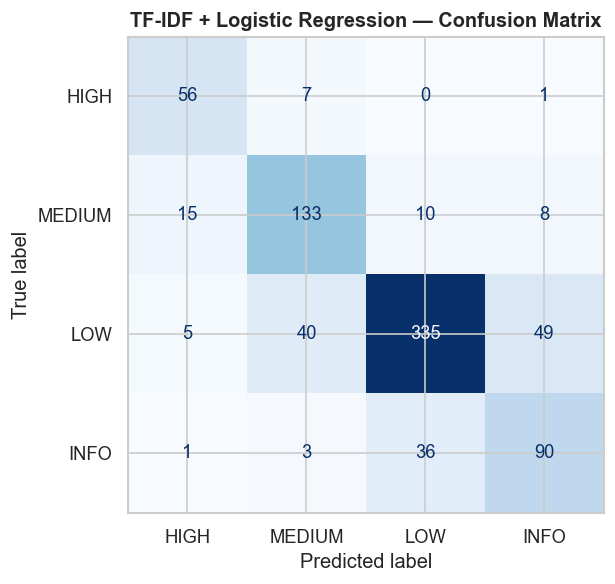


*** BASELINE Macro F1: 75.8% — write this down ***
Checkpoint 3.3 done


In [8]:
# Checkpoint 3.3 — Evaluate and inspect
y_pred_lr = lr.predict(X_test_tfidf)
metrics_lr = evaluate_model('TF-IDF + Logistic Regression', y_test, y_pred_lr, 'layer1_lr')

print(f'\n*** BASELINE Macro F1: {metrics_lr["Macro F1"]}% — write this down ***')
print('Checkpoint 3.3 done')

HIGH: mea, im, to, route, vortac, fl235, ord nav, clsd
INFO: 26, rnav gps, wet obs, iap, gps rwy, 64i, minimums, 2g4
LOW: twy, lgt, agl, sign, obst, tower, side, uas wi
MEDIUM: act, jfk, airspace, nav vor, 28r, moca, sfc side, intl


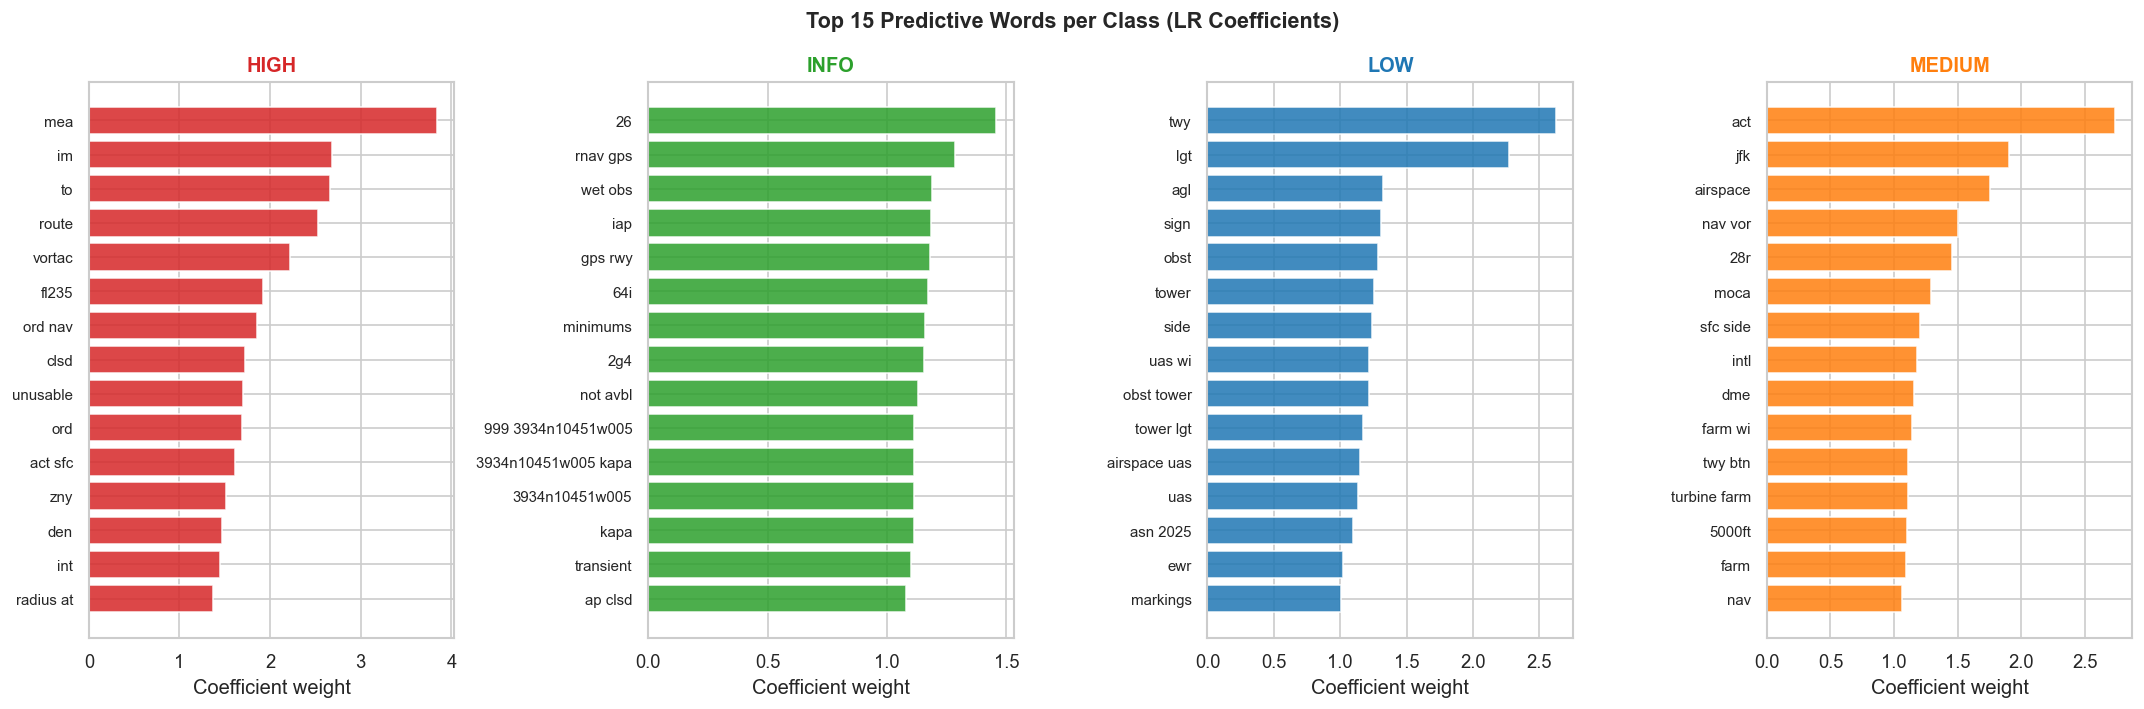

In [9]:
# Top predictive words per class
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, len(lr.classes_), figsize=(18, 6))
for idx, (cls, coefs) in enumerate(zip(lr.classes_, lr.coef_)):
    top_idx   = np.argsort(coefs)[-15:][::-1]
    top_words = feature_names[top_idx]
    top_coefs = coefs[top_idx]

    axes[idx].barh(list(reversed(top_words)), list(reversed(top_coefs)),
                   color=CRIT_COLORS.get(cls, '#888'), alpha=0.85, edgecolor='white')
    axes[idx].set_title(cls, fontweight='bold', color=CRIT_COLORS.get(cls, '#888'))
    axes[idx].set_xlabel('Coefficient weight')
    axes[idx].tick_params(axis='y', labelsize=9)
    print(f'{cls}: {", ".join(top_words[:8])}')

plt.suptitle('Top 15 Predictive Words per Class (LR Coefficients)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/layer1_top_words.png', bbox_inches='tight')
plt.show()

---
## Layer 2 — Sentence Embeddings + Random Forest
**Checkpoints 4.1, 4.2, 4.3**

Captures semantic meaning — two NOTAMs saying the same thing in different words will have similar vectors.

In [10]:
# Checkpoint 4.1 — Sentence embeddings
print(f'Loading: {EMBEDDING_MODEL_NAME}')

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

if EMBEDDINGS_CACHE_PATH.exists():
    print('Loading cached embeddings...')
    all_embeddings = np.load(EMBEDDINGS_CACHE_PATH)
else:
    print(f'Computing embeddings for {len(X):,} NOTAMs...')
    all_embeddings = embedder.encode(
        X,
        batch_size=128,
        show_progress_bar=True,
        device='mps'    # M2 Pro GPU acceleration
    )
    np.save(EMBEDDINGS_CACHE_PATH, all_embeddings)
    print(f'Saved to {EMBEDDINGS_CACHE_PATH.name}')

print(f'Shape: {all_embeddings.shape} — each NOTAM = {all_embeddings.shape[1]}d vector')
print('Checkpoint 4.1 done')

Loading: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing embeddings for 3,945 NOTAMs...


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Saved to embeddings_cache.npy
Shape: (3945, 384) — each NOTAM = 384d vector
Checkpoint 4.1 done


In [11]:
# Split embeddings using IDENTICAL indices as TF-IDF split
indices = np.arange(len(X))
idx_train, idx_test = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_emb = all_embeddings[idx_train]
X_test_emb  = all_embeddings[idx_test]
y_train_emb = y[idx_train]
y_test_emb  = y[idx_test]

assert np.array_equal(y_test, y_test_emb), 'Test set mismatch — check random state!'
print(f'Train: {X_train_emb.shape} | Test: {X_test_emb.shape}')
print('Test sets confirmed identical for fair comparison')

Train: (3156, 384) | Test: (789, 384)
Test sets confirmed identical for fair comparison


In [12]:
# Checkpoint 4.2 — Train Random Forest
print('Training Random Forest...')

rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight='balanced',
    random_state=RF_RANDOM_STATE,
    n_jobs=-1,    # all 10 M2 Pro cores
)
rf.fit(X_train_emb, y_train_emb)
joblib.dump(rf, EMBEDDING_MODEL_PATH)

cv_scores_rf = cross_val_score(rf, X_train_emb, y_train_emb, cv=5, scoring='f1_macro', n_jobs=-1)
print(f'5-fold CV Macro F1: {cv_scores_rf.mean()*100:.1f}% +/- {cv_scores_rf.std()*100:.1f}%')
print('Checkpoint 4.2 done')

Training Random Forest...
5-fold CV Macro F1: 73.4% +/- 0.8%
Checkpoint 4.2 done



------------------------------------------------------------
  Embeddings + Random Forest — Evaluation
------------------------------------------------------------
              precision    recall  f1-score   support

        HIGH       0.86      0.77      0.81        64
      MEDIUM       0.87      0.72      0.79       166
         LOW       0.79      0.94      0.86       429
        INFO       0.69      0.42      0.52       130

    accuracy                           0.80       789
   macro avg       0.80      0.71      0.74       789
weighted avg       0.79      0.80      0.78       789



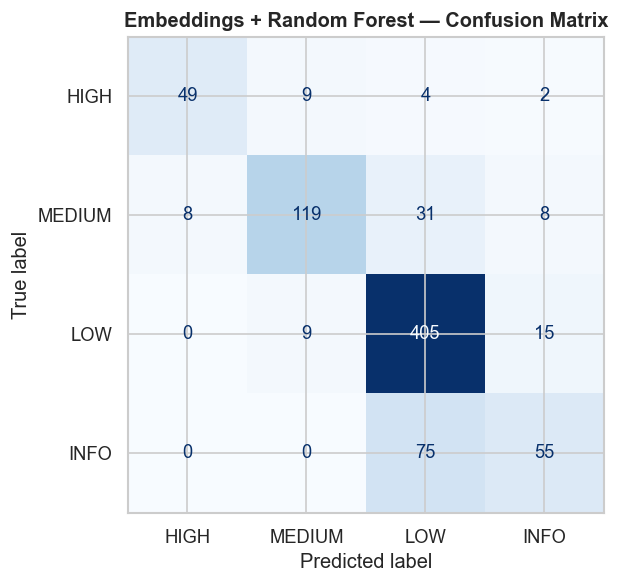

Checkpoint 4.3 done


In [13]:
# Checkpoint 4.3 — Evaluate Random Forest
y_pred_rf = rf.predict(X_test_emb)
metrics_rf = evaluate_model('Embeddings + Random Forest', y_test_emb, y_pred_rf, 'layer2_rf')
print('Checkpoint 4.3 done')

---
## Model Comparison
Side-by-side results on identical test data. This table goes in your README.


  MODEL COMPARISON — TEST SET RESULTS
                              Accuracy  Macro F1  Weighted F1  HIGH F1
Model                                                                 
TF-IDF + Logistic Regression      77.8      75.8         78.1     79.4
Embeddings + Random Forest        79.6      74.4         78.4     81.0

Winner per metric:
  Accuracy       -> Embeddings + Random Forest (+1.8%)
  Macro F1       -> TF-IDF + Logistic Regression (+1.4%)
  Weighted F1    -> Embeddings + Random Forest (+0.3%)
  HIGH F1        -> Embeddings + Random Forest (+1.6%)


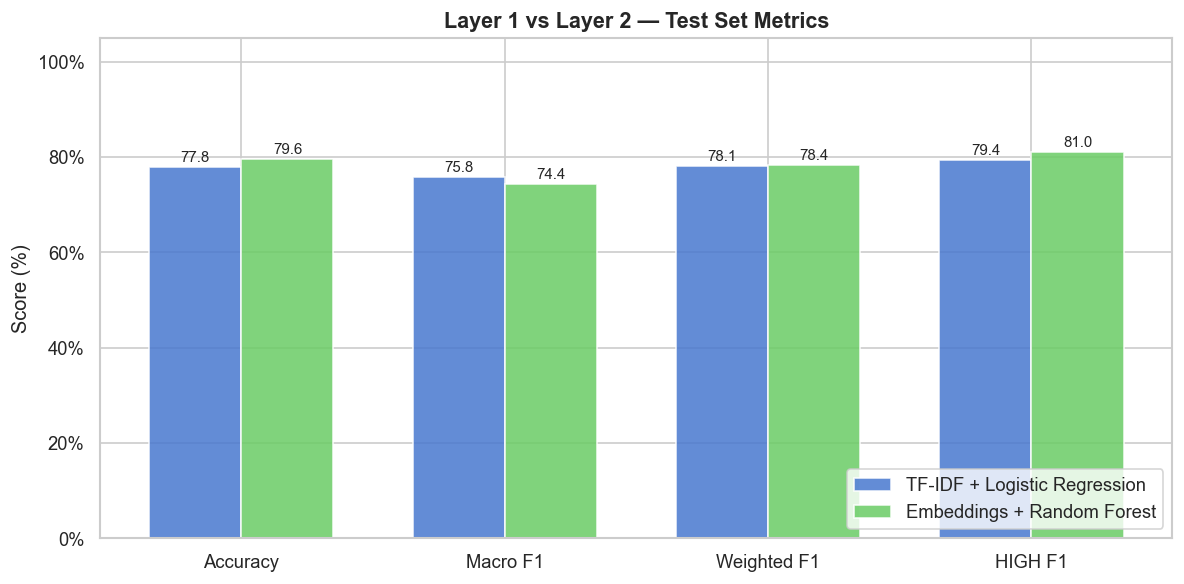

In [14]:
comparison = pd.DataFrame([metrics_lr, metrics_rf]).set_index('Model')

print('\n' + '='*65)
print('  MODEL COMPARISON — TEST SET RESULTS')
print('='*65)
print(comparison.to_string())
print('='*65)
print('\nWinner per metric:')
for col in comparison.columns:
    winner = comparison[col].idxmax()
    delta  = comparison[col].max() - comparison[col].min()
    print(f'  {col:<14} -> {winner} (+{delta:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison.columns))
width = 0.35
bars1 = ax.bar(x - width/2, comparison.iloc[0], width, label=comparison.index[0],
               color='#4878cf', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison.iloc[1], width, label=comparison.index[1],
               color='#6acc65', alpha=0.85, edgecolor='white')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(comparison.columns)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Layer 1 vs Layer 2 — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../notebooks/figures/model_comparison.png', bbox_inches='tight')
plt.show()

---
## UMAP Visualization
Reduces 384D embeddings to 2D. Well-separated clusters = the model learned real structure.

In [16]:
try:
    import umap
    UMAP_AVAILABLE = True
    print('UMAP available')
except ImportError:
    print('UMAP not found. Install with: pip install umap-learn')
    print('Falling back to t-SNE...')
    UMAP_AVAILABLE = False

UMAP available


In [17]:
SAMPLE_SIZE = min(2000, len(all_embeddings))
sample_idx  = np.random.RandomState(RANDOM_STATE).choice(len(all_embeddings), SAMPLE_SIZE, replace=False)
sample_emb  = all_embeddings[sample_idx]
sample_y    = y[sample_idx]

print(f'Reducing {SAMPLE_SIZE:,} embeddings to 2D...')

if UMAP_AVAILABLE:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE, verbose=True)
else:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE, n_iter=1000, verbose=1)

coords_2d = reducer.fit_transform(sample_emb)
print(f'Done. Shape: {coords_2d.shape}')

Reducing 2,000 embeddings to 2D...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Mar 10 02:44:50 2026 Construct fuzzy simplicial set
Tue Mar 10 02:44:52 2026 Finding Nearest Neighbors
Tue Mar 10 02:44:54 2026 Finished Nearest Neighbor Search
Tue Mar 10 02:44:55 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Mar 10 02:44:57 2026 Finished embedding
Done. Shape: (2000, 2)


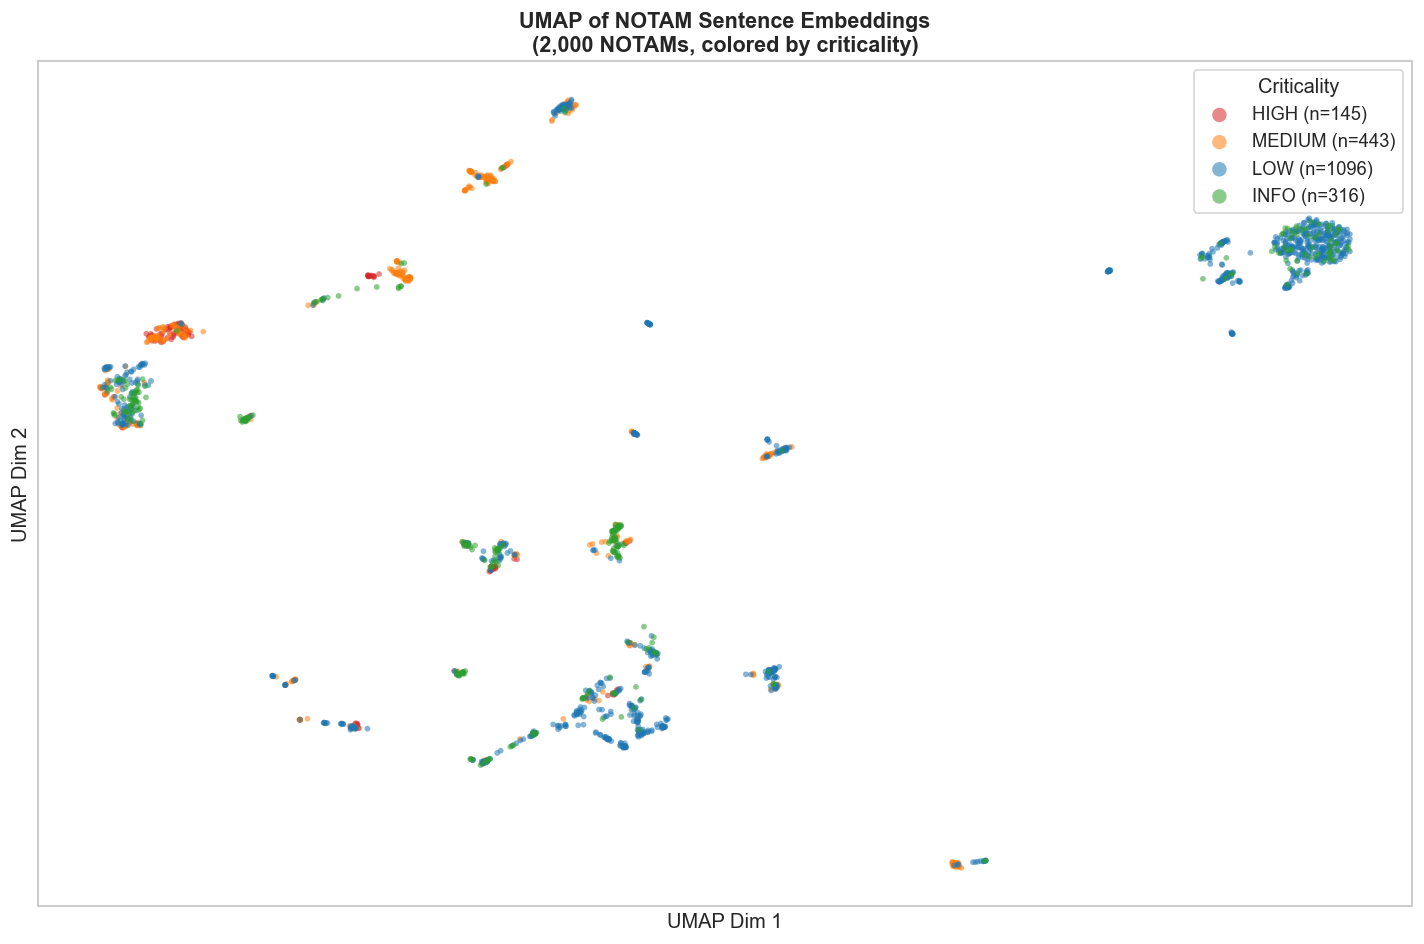

Save this plot — it goes in your README.


In [18]:
method = 'UMAP' if UMAP_AVAILABLE else 't-SNE'

fig, ax = plt.subplots(figsize=(12, 8))
for crit in CRITICALITY_LEVELS:
    mask = sample_y == crit
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=CRIT_COLORS[crit], label=f'{crit} (n={mask.sum()})',
               alpha=0.55, s=12, edgecolors='none')

ax.set_title(f'{method} of NOTAM Sentence Embeddings\n({SAMPLE_SIZE:,} NOTAMs, colored by criticality)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'{method} Dim 1')
ax.set_ylabel(f'{method} Dim 2')
ax.legend(markerscale=2.5, title='Criticality')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig('../notebooks/figures/umap_embeddings.png', bbox_inches='tight', dpi=150)
plt.show()
print('Save this plot — it goes in your README.')

---
## Phase 3 Summary

In [19]:
print('=' * 65)
print('  PHASE 3 COMPLETE')
print('=' * 65)
print(f'''
Layer 1 (TF-IDF + LR)
  Macro F1:  {metrics_lr['Macro F1']}%
  HIGH F1:   {metrics_lr['HIGH F1']}%

Layer 2 (Embeddings + RF)
  Macro F1:  {metrics_rf['Macro F1']}%
  HIGH F1:   {metrics_rf['HIGH F1']}%
''')
winner = 'Random Forest' if metrics_rf['Macro F1'] >= metrics_lr['Macro F1'] else 'Logistic Regression'
print(f'Winner: {winner}')
print('=' * 65)
print('Next: 04_anomaly_detection.ipynb')

  PHASE 3 COMPLETE

Layer 1 (TF-IDF + LR)
  Macro F1:  75.8%
  HIGH F1:   79.4%

Layer 2 (Embeddings + RF)
  Macro F1:  74.4%
  HIGH F1:   81.0%

Winner: Logistic Regression
Next: 04_anomaly_detection.ipynb
